# step 1 : loading the reqirmerments

In [ ]:
# Week 2: Advanced Data Visualization and Storytelling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Step 2: Load the cleaned dataset

In [ ]:
df = pd.read_csv("cleaned_fake_job_postings.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (6841, 19)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         des

In [ ]:
print(df["fraudulent"].value_counts())

fraudulent
0.0    6525
1.0     315
Name: count, dtype: int64


# Step 3: Create a fraud-label column

In [ ]:
df["job_type"] = df["fraudulent"].map({
    0: "Genuine",
    1: "Fraudulent"
})

print(df["job_type"].value_counts())

job_type
Genuine       6525
Fraudulent     315
Name: count, dtype: int64


# Step 4: Visualization 1 — Fraud Rate by Employment Type

Question we're answering

Are some employment types associated with a higher proportion of fraudulent postings?

Use fraud rate, not just number of postings.

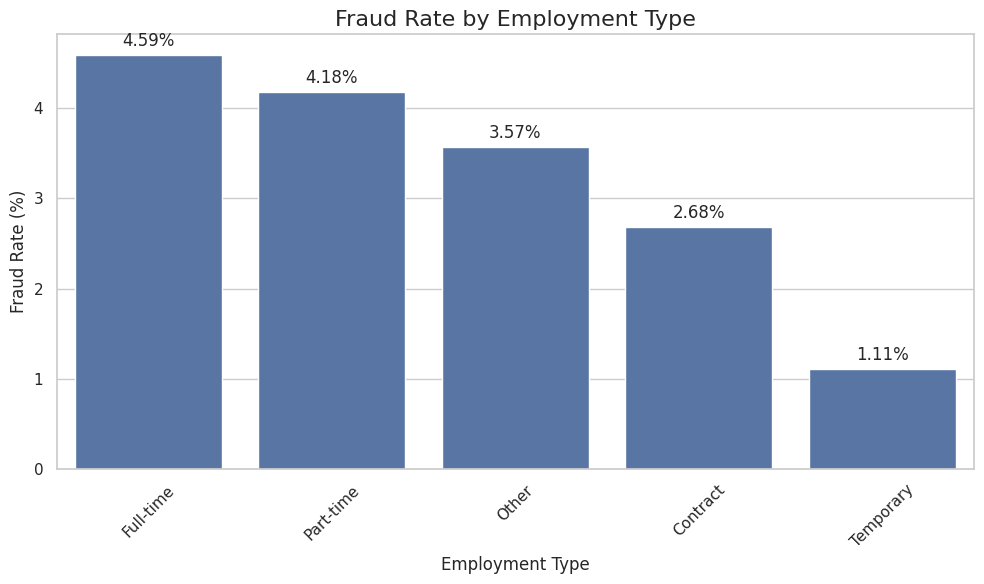

In [ ]:
employment_fraud = (
    df.groupby("employment_type")["fraudulent"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=employment_fraud.index,
    y=employment_fraud.values
)

plt.title("Fraud Rate by Employment Type", fontsize=16)
plt.xlabel("Employment Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

for i, value in enumerate(employment_fraud.values):
    ax.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("fraud_rate_by_employment_type.png", dpi=300)
plt.show()

**`Story for the report`**

This visualization compares the proportion of fraudulent postings across employment categories. Fraud rate is used instead of raw posting count because the dataset contains substantially different numbers of postings across employment types. The visualization helps identify whether certain employment categories deserve additional attention during fraud screening.

# Step 5: Visualization 2 — Fraud Rate by Required Experience

**Question**

Does fraud prevalence vary according to the experience level requested?

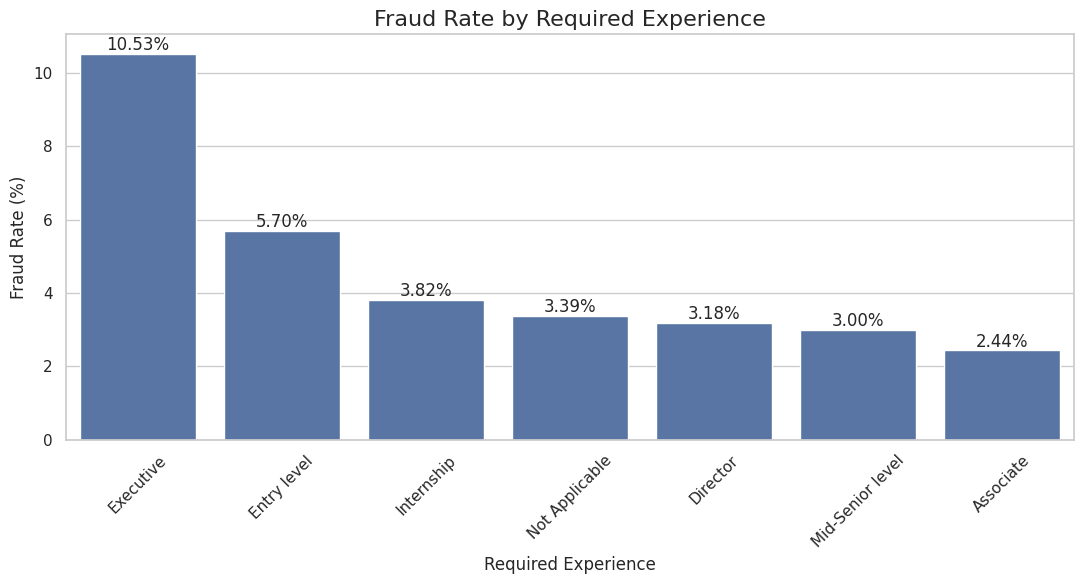

In [ ]:
experience_fraud = (
    df.groupby("required_experience")["fraudulent"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=experience_fraud.index,
    y=experience_fraud.values
)

plt.title("Fraud Rate by Required Experience", fontsize=16)
plt.xlabel("Required Experience")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

for i, value in enumerate(experience_fraud.values):
    ax.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("fraud_rate_by_experience.png", dpi=300)
plt.show()

**`Story`**

This visualization examines whether fraudulent job postings are distributed differently across required experience levels. Understanding these differences can help recruitment platforms identify categories that may require additional verification.

# Step 6: Visualization 3 — Fraud Rate by Education

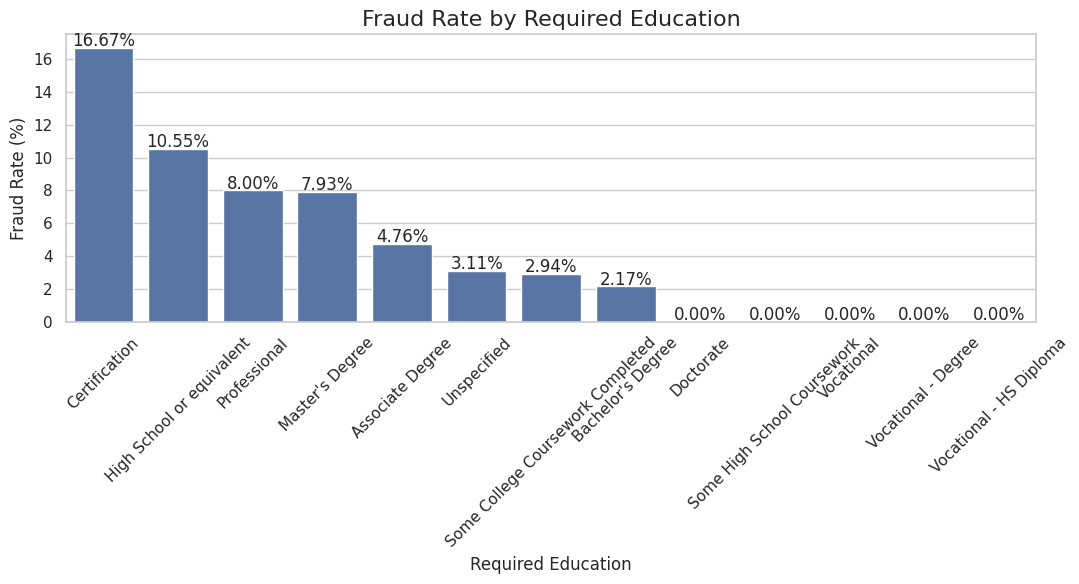

In [ ]:
education_fraud = (
    df.groupby("required_education")["fraudulent"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=education_fraud.index,
    y=education_fraud.values
)

plt.title("Fraud Rate by Required Education", fontsize=16)
plt.xlabel("Required Education")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

for i, value in enumerate(education_fraud.values):
    ax.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("fraud_rate_by_education.png", dpi=300)
plt.show()

**`Story`**

The chart compares fraudulent-posting rates across education requirements. It provides a demographic-style view of job requirements and can reveal categories where the observed fraud rate differs from the overall dataset rate.

# Step 7: Visualization 4 — Top Industries by Fraud Rate

There may be many industries, so don't plot all of them.

First calculate the number of postings:

In [ ]:
industry_counts = df["industry"].value_counts()

industry_fraud = (
    df.groupby("industry")["fraudulent"]
    .agg(["mean", "count"])
)

industry_fraud["fraud_rate"] = industry_fraud["mean"] * 100

industry_fraud = industry_fraud[
    industry_fraud["count"] >= 30
]

top_industries = (
    industry_fraud
    .sort_values("fraud_rate", ascending=False)
    .head(10)
)

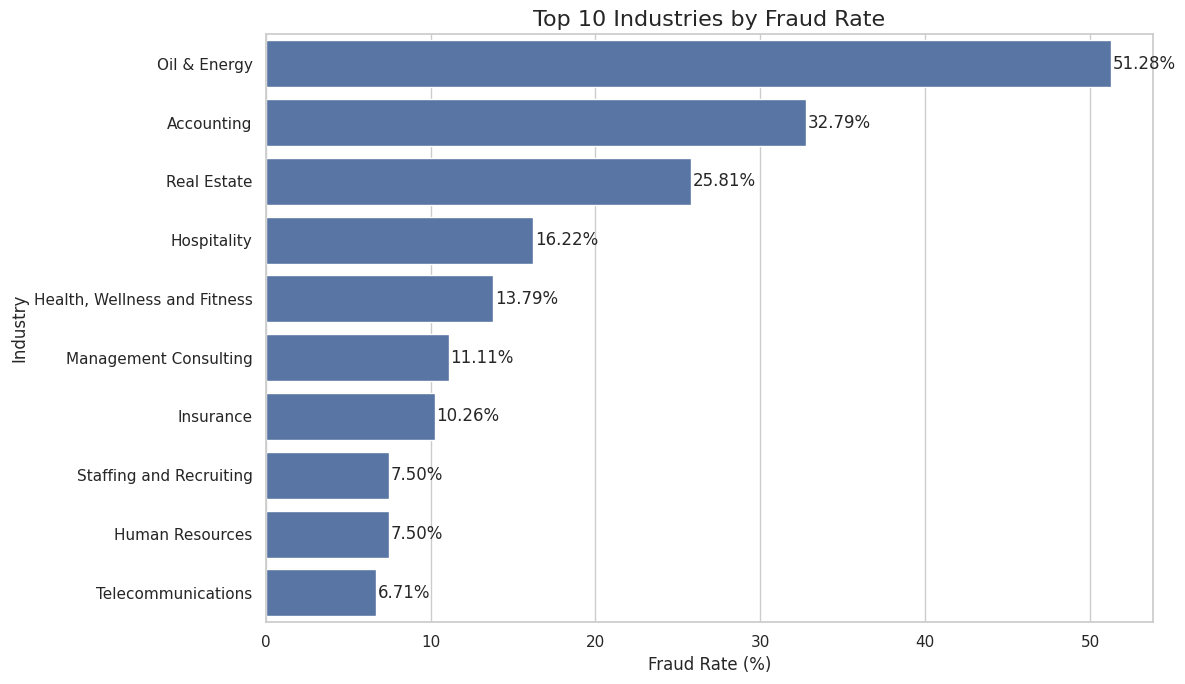

In [ ]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top_industries["fraud_rate"],
    y=top_industries.index
)

plt.title("Top 10 Industries by Fraud Rate", fontsize=16)
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Industry")

for i, value in enumerate(top_industries["fraud_rate"]):
    ax.text(value + 0.1, i, f"{value:.2f}%", va="center")

plt.tight_layout()
plt.savefig("top_industries_fraud_rate.png", dpi=300)
plt.show()

**Why did we use count >= 30?**

Very important for your report.

An industry with only 1–2 job postings could show a fraud rate of 100%, but that doesn't mean the industry is genuinely high-risk.

Requiring at least 30 postings makes the comparison more meaningful.



**`Story`**

The visualization highlights the ten industries with the highest observed fraud rates among industries having at least 30 postings. Applying a minimum sample-size threshold reduces the risk of interpreting extremely small groups as meaningful patterns.

# Step 8: Visualization 5 — Company Logo vs Fraud Rate

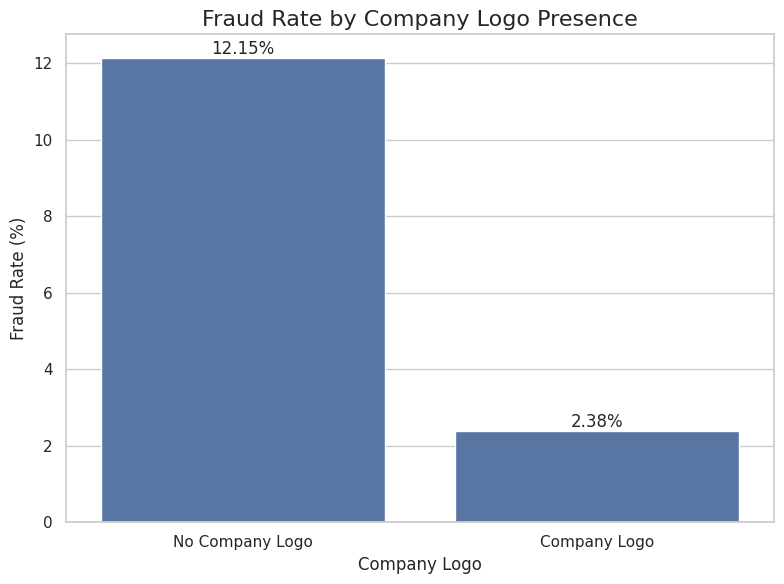

In [ ]:
logo_fraud = (
    df.groupby("has_company_logo")["fraudulent"]
    .mean() * 100
)

logo_labels = {
    0: "No Company Logo",
    1: "Company Logo"
}

logo_fraud.index = logo_fraud.index.map(logo_labels)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=logo_fraud.index,
    y=logo_fraud.values
)

plt.title("Fraud Rate by Company Logo Presence", fontsize=16)
plt.xlabel("Company Logo")
plt.ylabel("Fraud Rate (%)")

for i, value in enumerate(logo_fraud.values):
    ax.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("fraud_rate_company_logo.png", dpi=300)
plt.show()

**`Story`**

This visualization compares fraud rates between postings with and without company logos. The feature may provide a useful signal because legitimate organizations may be more likely to provide recognizable company branding. However, the presence or absence of a logo should not be treated as proof of legitimacy or fraud.

# Step 9: Visualization 6 — Correlation Heatmap

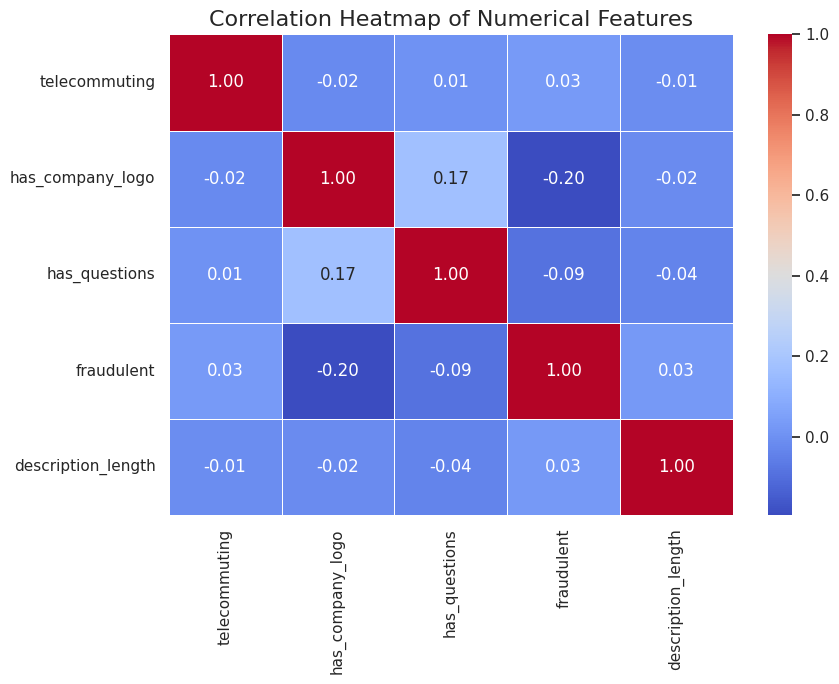

In [ ]:
numeric_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "fraudulent",
    "description_length"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

**`# Story`**

The correlation heatmap summarizes the relationships among the numerical and binary variables. It provides a compact overview of which variables have stronger or weaker linear associations with the fraudulent target. Correlation should be interpreted as association rather than causation.

# Step 10: Create a summary table

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Labeled Postings",
        "Genuine Postings",
        "Fraudulent Postings",
        "Fraudulent Rate"
    ],
    "Value": [
        len(df),
        (df["fraudulent"] == 0).sum(),
        (df["fraudulent"] == 1).sum(),
        f"{df['fraudulent'].mean() * 100:.2f}%"
    ]
})

summary

,Metric,Value
0,Total Labeled Postings,6841
1,Genuine Postings,6525
2,Fraudulent Postings,315
3,Fraudulent Rate,4.61%
